## Лабораторна робота 4. **REGRESSION** 📈

# Опис вибірки "Motorbike Ambulance Calls"


Аварії за участю мотоциклів та відповідні виклики швидкої допомоги сильно залежать від екологічних та сезонних умов, таких як погодні умови, опади, день тижня, сезон, година дня тощо. Дані збирались протягом двох років щогодини та потім співвідносилися з відповідною погодою та сезонністю.

Основні характеристики вибірки `motorbike_ambulance_calls.csv`:

              - index: record index
              - date : date
              - season : season (1:springer, 2:summer, 3:fall, 4:winter)
              - yr : year (0: 2011, 1:2012)
              - mnth : month ( 1 to 12)
              - hr : hour (0 to 23)
              - holiday : whether day is holiday or not
              - weekday : day of the week
              - workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
              -  weathersit :
                      - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
                      - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
                      - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
                      - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
              - temp : Normalized temperature in Celsius. The values are divided to 41 (max)
              - atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
              - hum: Normalized humidity. The values are divided to 100 (max)
              - windspeed: Normalized wind speed. The values are divided to 67 (max)
              - cnt: count of total ambulance calls

## Імпорт необхідних бібліотек та завантаження даних

**Завдання 1** підготовка даних до опрацювання

1. завантажте вибірку `motorbike_ambulance_calls.csv`;   
2. підключіть необхідні бібліотеки;  
3. вивести основну статистичну інформацію по числовим змінним;  
4. окремо вивести максимальні та мінімальні значення по всім змінним;  
5. вивести розмірність датасету;

In [18]:
import pandas as pd
import numpy as np
import scipy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from datetime import date, time, datetime
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy.stats import linregress

In [2]:
def get_data(data_path: str):
  data = pd.read_csv(data_path, index_col=0)
  return data

In [4]:
data = get_data('./motorbike_ambulance_calls.csv')
print("main info", data.describe())
print("shape of dataset", data.shape)

main info                  yr          mnth            hr       holiday       weekday  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.502561      6.537775     11.546752      0.028770      3.003683   
std        0.500008      3.438776      6.914405      0.167165      2.005771   
min        0.000000      1.000000      0.000000      0.000000      0.000000   
25%        0.000000      4.000000      6.000000      0.000000      1.000000   
50%        1.000000      7.000000     12.000000      0.000000      3.000000   
75%        1.000000     10.000000     18.000000      0.000000      5.000000   
max        1.000000     12.000000     23.000000      1.000000      6.000000   

         workingday    weathersit          temp         atemp           hum  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.682721      1.425283      0.496987      0.475775      0.627229   
std        0.465431      0.639357      0.

**Завдання 2** перевірити типи даних та перевірте кількість даних по кожній змінній.

In [5]:
for col in data.columns:
    print(f"{col}: {data[col].count()}, type: {data[col].dtype}")

date: 17379, type: object
season: 17379, type: object
yr: 17379, type: int64
mnth: 17379, type: int64
hr: 17379, type: int64
holiday: 17379, type: int64
weekday: 17379, type: int64
workingday: 17379, type: int64
weathersit: 17379, type: int64
temp: 17379, type: float64
atemp: 17379, type: float64
hum: 17379, type: float64
windspeed: 17379, type: float64
cnt: 17379, type: int64


**Завдання 3** пепевірте всі змінні на наявність пропусків.

In [6]:
mising_values = data.isna().sum()
print('mising_values', mising_values)

mising_values date          0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


**Висновки з 1-3 завдання (детальні)**


1. 17379 рядків 14 колонок
2. к-сть даних в кожній змінній співпадає
3. всі змінні цілісні  та не мають пропусків



**Завдання 4** перетворіть змінну `date` в **date type**. Визначте часові межі датасету.

In [7]:
def tranform_date(df: pd.DataFrame, date_col_name: str):
    time_list = []
    datetime_list = []

    for hr in df['hr']:
        time_list.append(hr)

    for i,date_time in enumerate(df[date_col_name]):
        month, day, year = date_time.split("/")
        month = int(month)
        day = int(day)
        year = int(year)
        new_date = date(year, month, day)
        created_time = time(time_list[i], 0)
        new_datetime = datetime.combine(new_date, created_time)
        datetime_list.append(new_datetime)
    return df, datetime_list

data, datetime_list = tranform_date(data, 'date')
data['date_type'] = datetime_list

last_datetime_obj = datetime_list[len(datetime_list) - 1]
first_datetime_obj = datetime_list[0]

time_interval = last_datetime_obj - first_datetime_obj
print('time_interval', time_interval)
print(data['date_type'])

time_interval 730 days, 23:00:00
index
1        0011-01-01 00:00:00
2        0011-01-01 01:00:00
3        0011-01-01 02:00:00
4        0011-01-01 03:00:00
5        0011-01-01 04:00:00
                ...         
17375    0012-12-31 19:00:00
17376    0012-12-31 20:00:00
17377    0012-12-31 21:00:00
17378    0012-12-31 22:00:00
17379    0012-12-31 23:00:00
Name: date_type, Length: 17379, dtype: object


In [8]:
def get_time_limits(df: pd.DataFrame, date_col_name: str):
  first_day = df[date_col_name].iat[0]
  last_day = df[date_col_name].iat[len(df) - 1]
  print(f" First day of dataset - {first_day}.\n Last day of dataset - {last_day}")

get_time_limits(data, 'date_type')

 First day of dataset - 0011-01-01 00:00:00.
 Last day of dataset - 0012-12-31 23:00:00


ці дані мають чітко 2 роки інтервалу

#Аналіз категоріальних змінних

**Завдання 5** виділити категоріальні змінні в окремий датасет







In [11]:
categorial_columns = ['season', 'yr', 'hr', 'weekday', 'workingday', 'weathersit', 'holiday', 'mnth']
data_categorical = data[categorial_columns]


**Завдання 6** перетворіть змінну `season` в числову шкалу.

In [12]:
def encode_season(df: pd.DataFrame, season_col_name: str):
  seasons_list = []
  for season in df[season_col_name]:

      if season =='spring':
        seasons_list.append(1)

      elif season == 'summer':
        seasons_list.append(2)

      elif season == 'autumn':
        seasons_list.append(3)

      else:
        seasons_list.append(4)

  df[season_col_name] = seasons_list
  return df

data = encode_season(data, 'season')
print(data['season'])

index
1        1
2        1
3        1
4        1
5        1
        ..
17375    1
17376    1
17377    1
17378    1
17379    1
Name: season, Length: 17379, dtype: int64


**Завдання 7** побудувати графіки `countplot` по всім категоріальним змінним

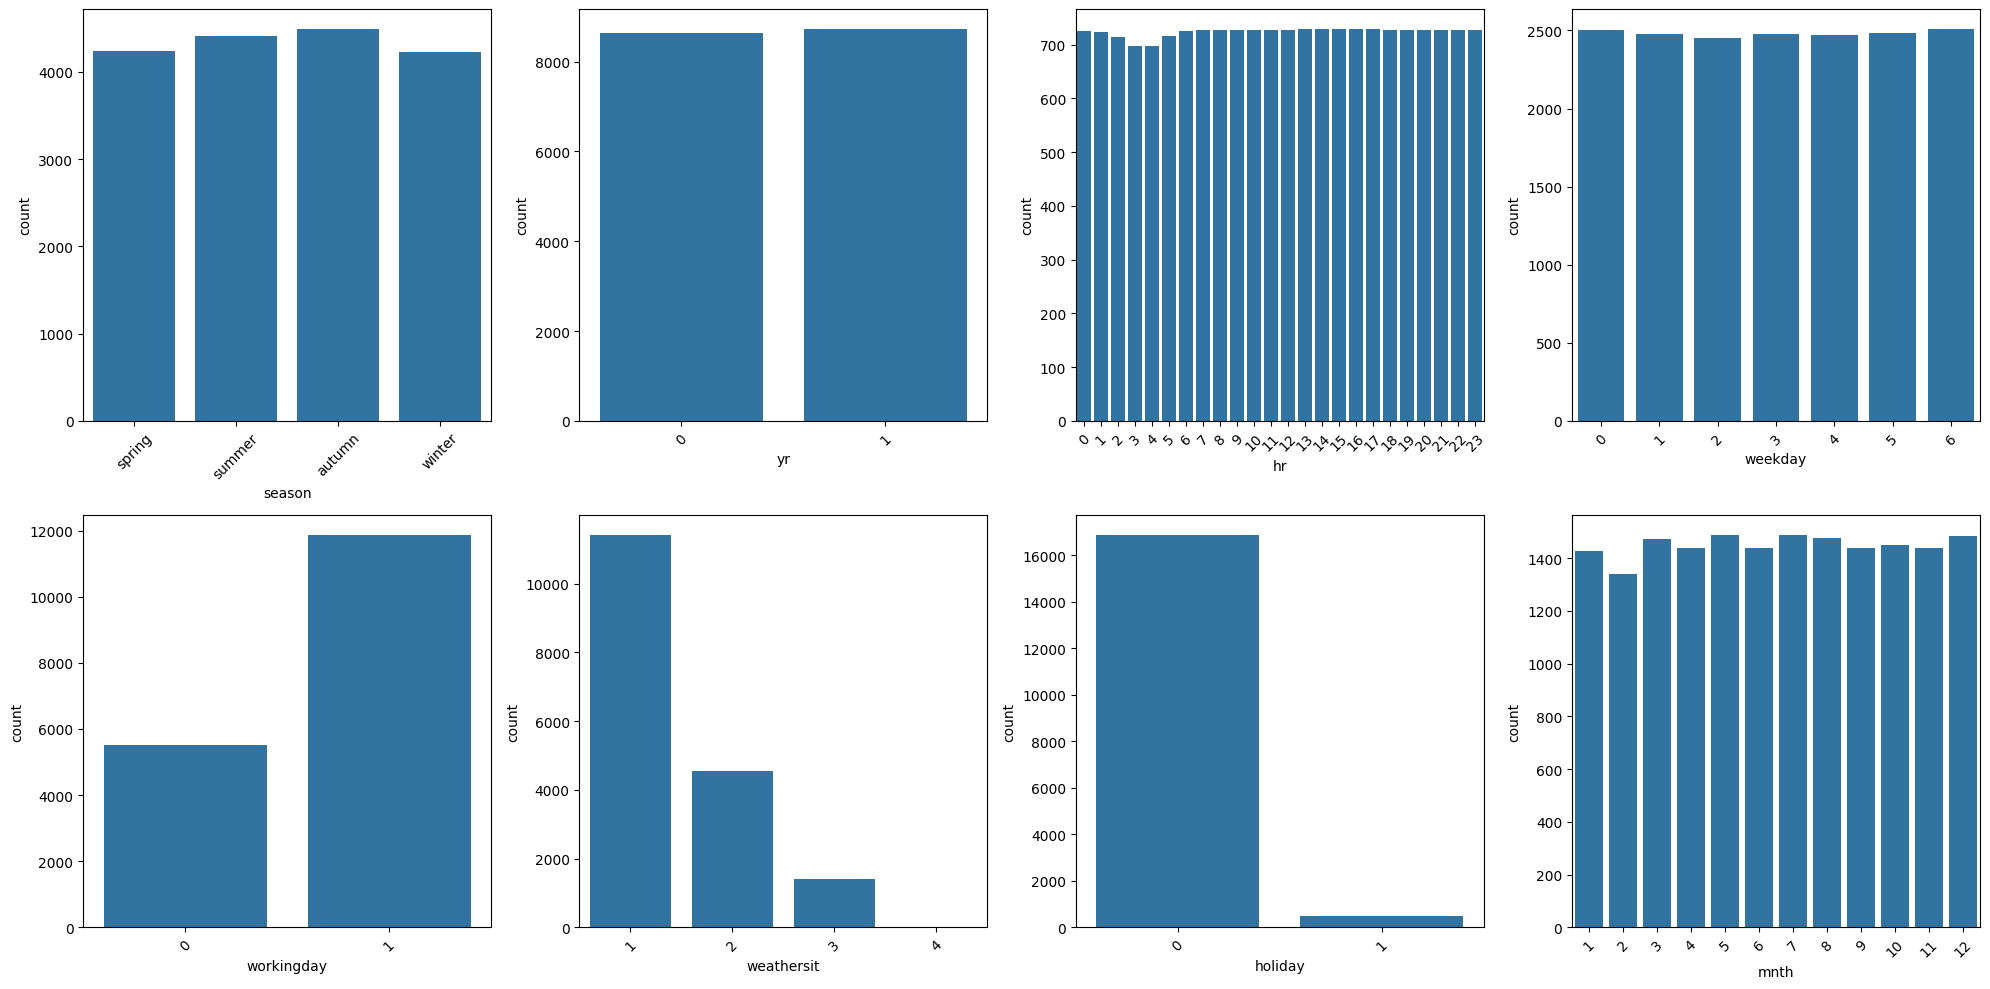

In [13]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
for variable, subplot in zip(data_categorical, ax.flatten()):
    sns.countplot(x=variable, data=data_categorical, ax=subplot)
    for label in subplot.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.show()

**Висновки з 5-7 завдання (детальні)**

1. Можна зробити висновок, що в даному наборі даних категоріальними є такі стовпці: season, date, hour, weekday, month, holiday, weathershit, year

2. Доцільно змінити тип колонки season з рядка на ціле число, що дозволить зробити її категоріальною

3. З семантичних графіків можна помітити що розподіл даних майже однаковий у всіх випадках, за винятком графіків, що стосуються робочих днів. Зокрема, виклики швидкої допомоги частіше траплялися в робочі дні порівняно з вихідними, що є логічним, оскільки кількість робочих днів більше. Однак, цікавим є той факт, що найбільше викликів швидкої допомоги припало не на дні з поганими погодними умовами, а навпаки, на дні з хорошими погодними умовами.



#Аналіз числових змінних

**Завдання 8** виділити числові змінні в окремий датасет

In [14]:
numerical_cols = ['atemp', 'temp', 'hum', 'windspeed', 'hr', 'cnt']

data_numerical = data[numerical_cols]
print('data_numerical', data_numerical)

data_numerical         atemp  temp   hum  windspeed  hr  cnt
index                                        
1      0.2879  0.24  0.81     0.0000   0   16
2      0.2727  0.22  0.80     0.0000   1   40
3      0.2727  0.22  0.80     0.0000   2   32
4      0.2879  0.24  0.75     0.0000   3   13
5      0.2879  0.24  0.75     0.0000   4    1
...       ...   ...   ...        ...  ..  ...
17375  0.2576  0.26  0.60     0.1642  19  119
17376  0.2576  0.26  0.60     0.1642  20   89
17377  0.2576  0.26  0.60     0.1642  21   90
17378  0.2727  0.26  0.56     0.1343  22   61
17379  0.2727  0.26  0.65     0.1343  23   49

[17379 rows x 6 columns]


**Завдання 9** побудуйте гістограми розподілу по всім числовим змінним

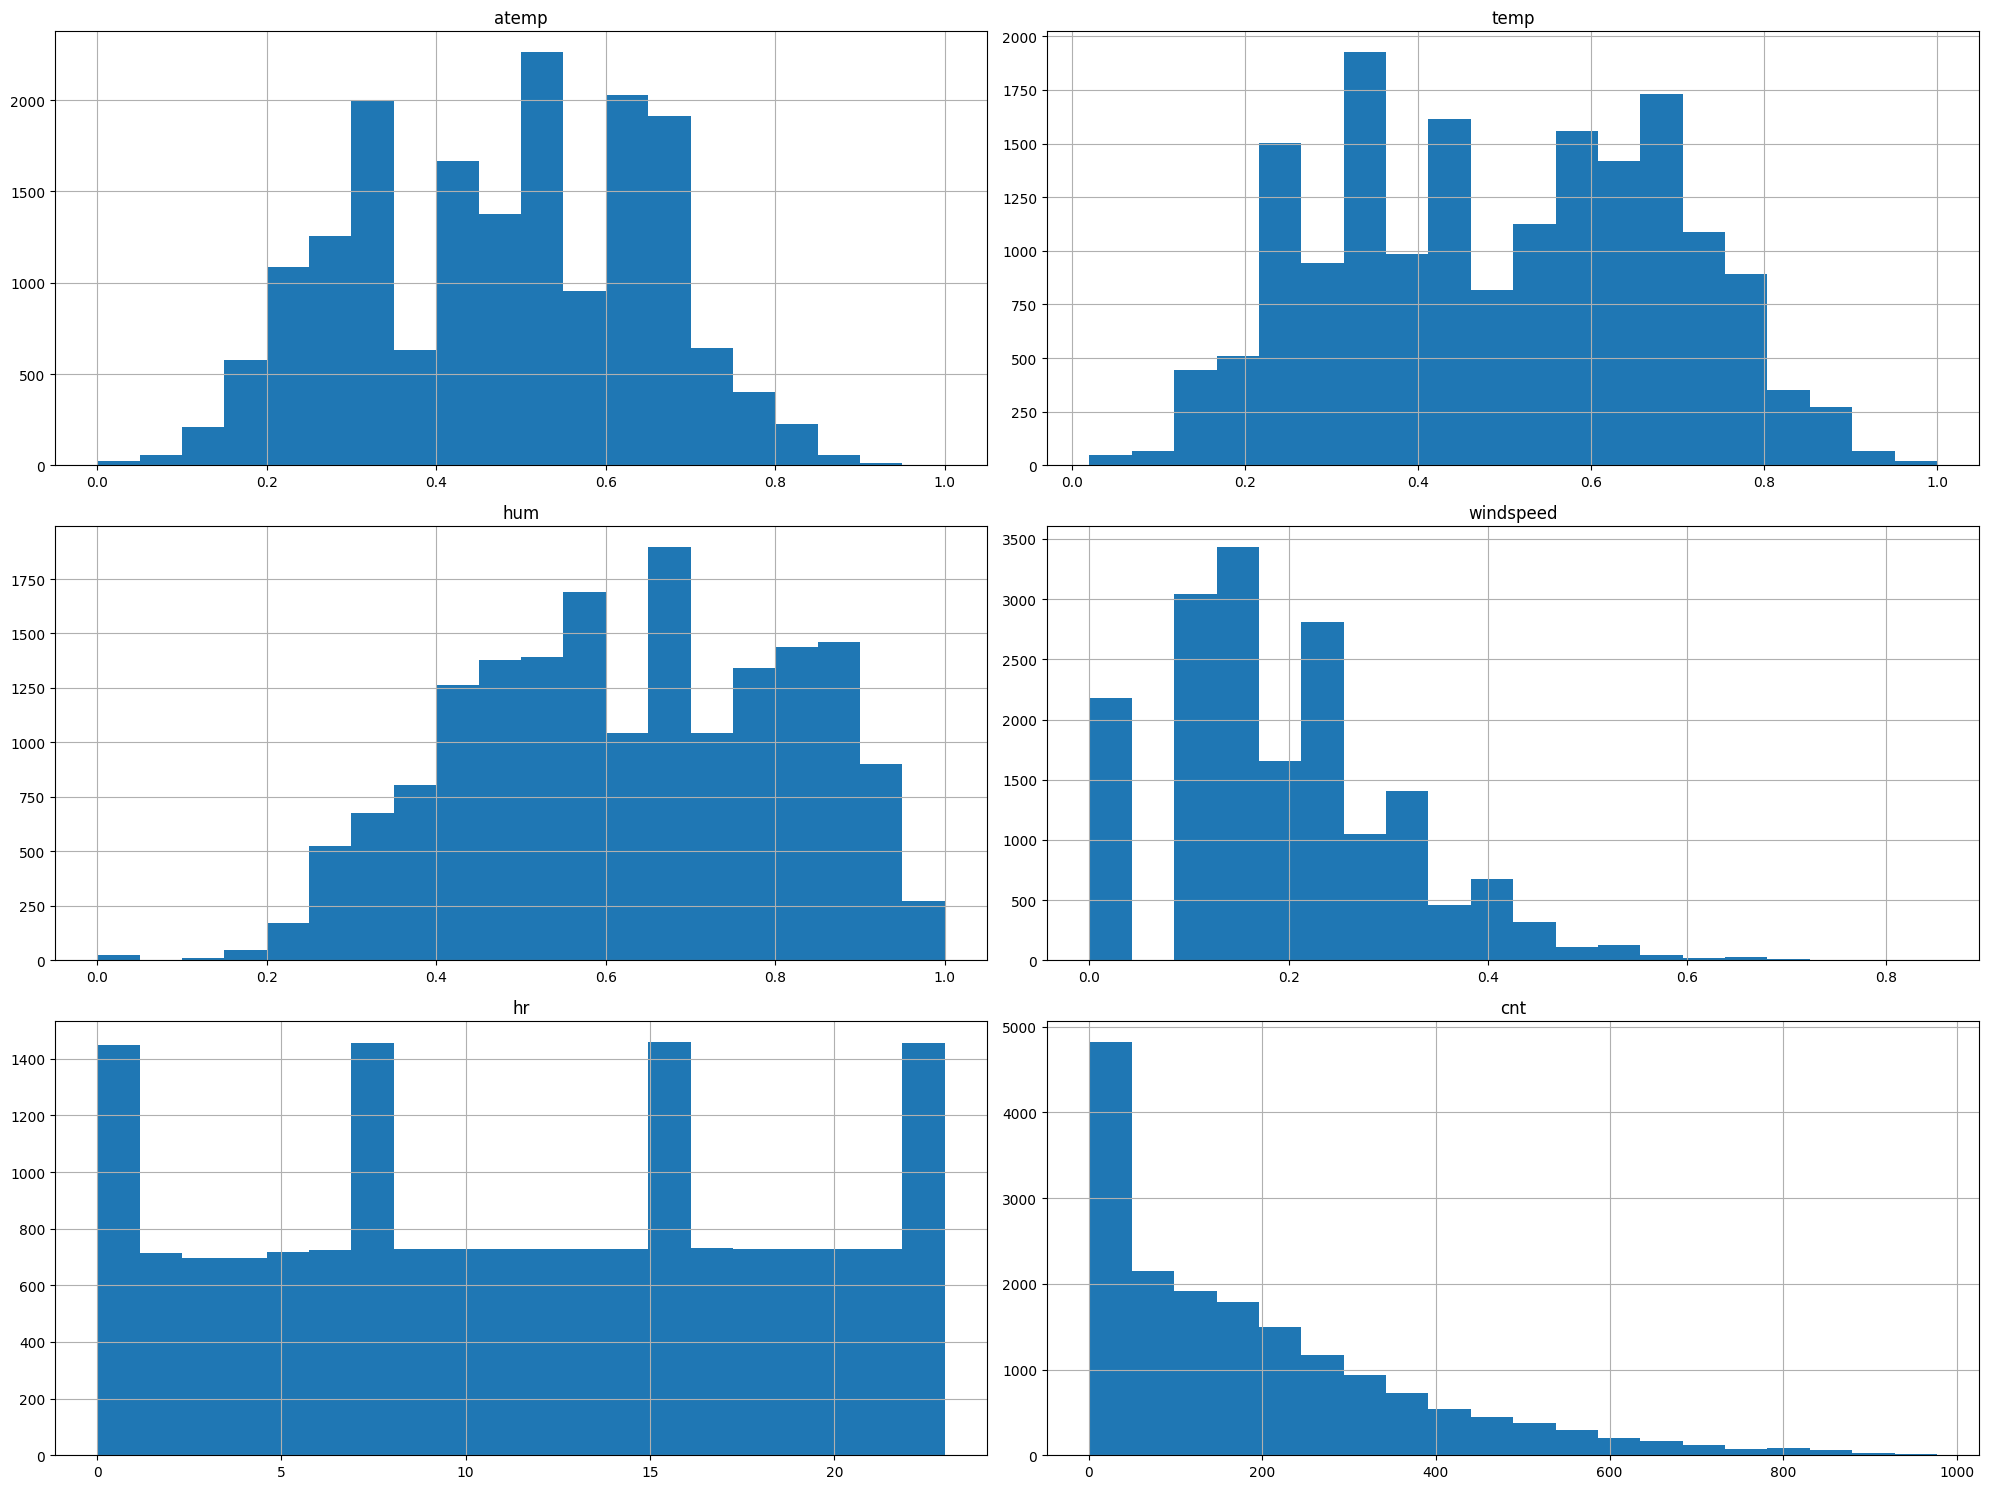

In [15]:
fig, ax = plt.subplots(3, 2, figsize=(20, 15))
for variable, subplot in zip(data_numerical, ax.flatten()):
    data_numerical[variable].hist(ax=subplot, bins=20)
    subplot.set_title(variable)

plt.tight_layout()
plt.show()

**Завдання 10** побудуйте гістограму розподілу цільової змінної та розрахуйте коефіціент нахилу

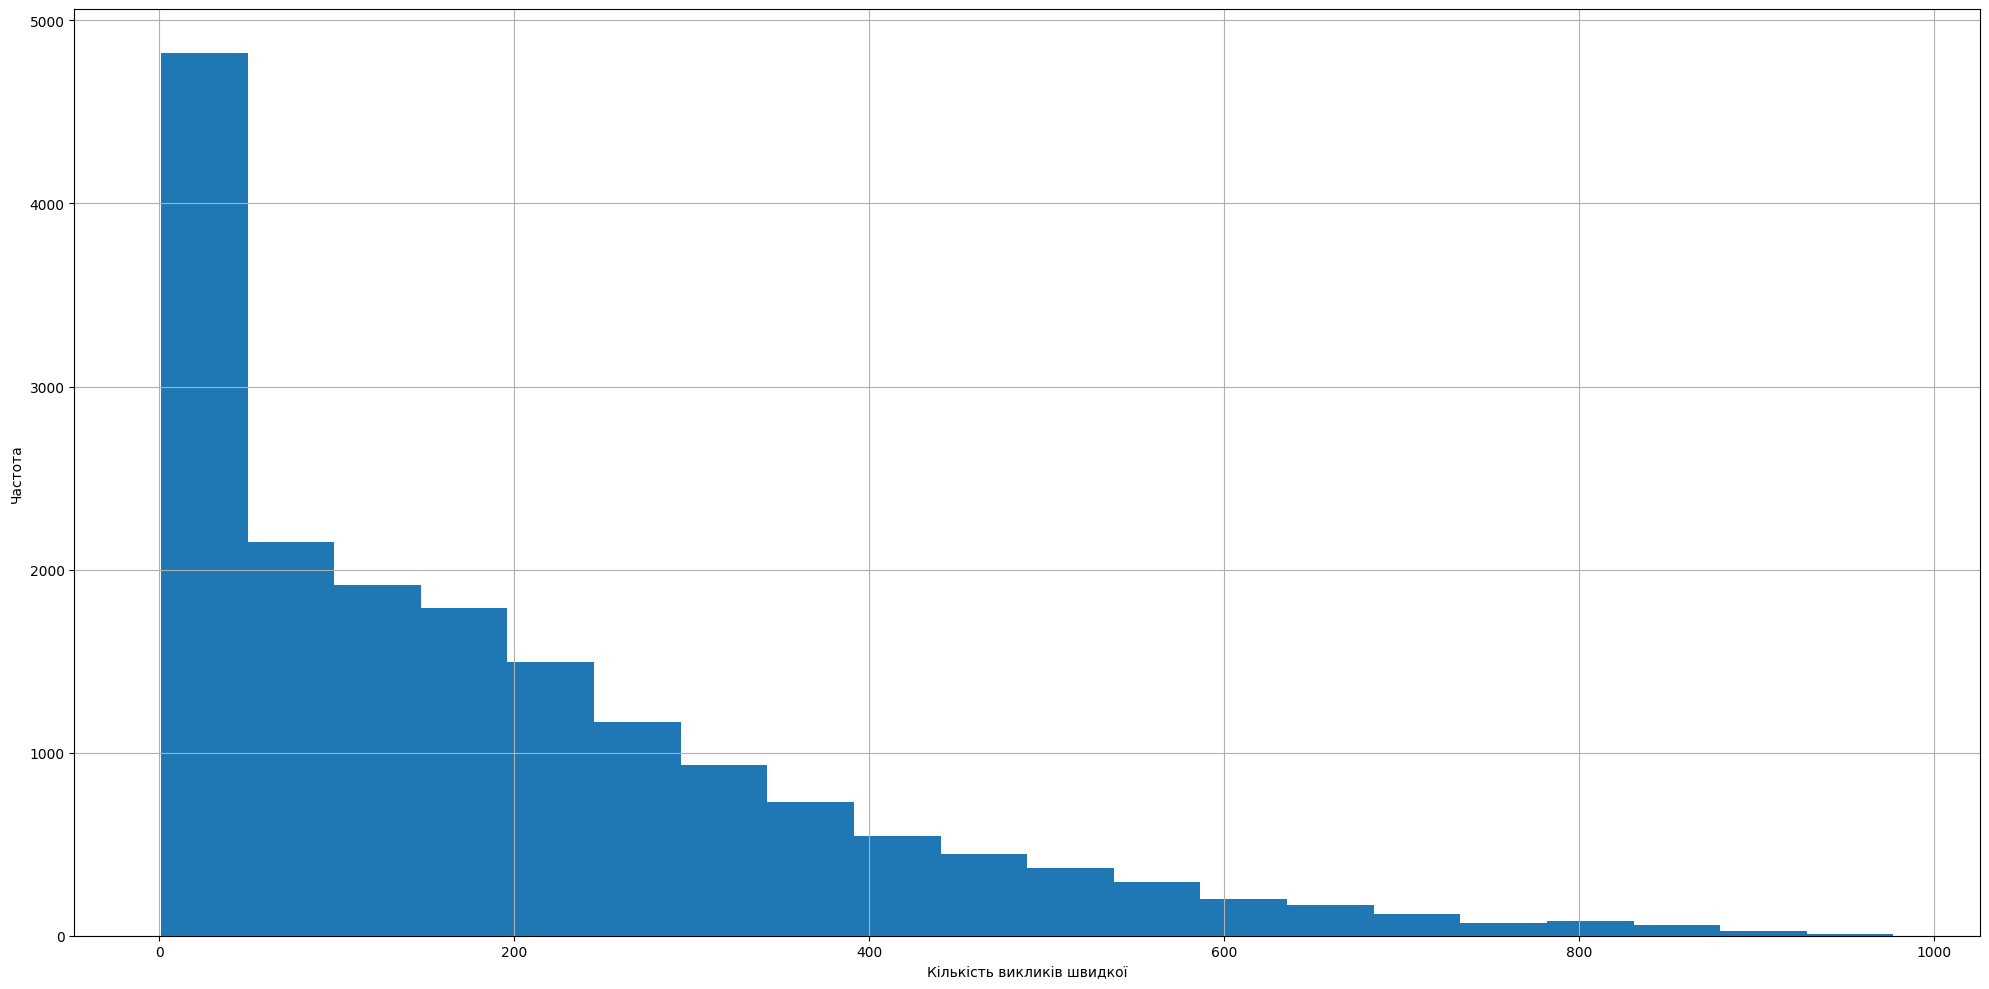

slope coefficient 0.010064609532772021


In [19]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
data['cnt'].hist(ax=ax, bins=20)


plt.xlabel("Кількість викликів швидкої")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(data.index, data['cnt'])
print('slope coefficient', slope)

**Висновки з 8-10 завдання (детальні)**

1. Ззмінні `'atemp'`, `'temp'`, `'hum'`, `'windspeed'` і `'hr'` можна віднести до числових.  
2. Найбільша кількість викликів швидкої спостерігається в години пік, а також у ранковий та пізній час.  
3. Розподіл даних нагадує експоненційну залежність, а коефіцієнт нахилу становить 0.01006.



#Аналіз взаємозв'язків між числовими і категоріальними змінними

**Завдання 11** побудуйте графіки співвідношення `scatterplot` між всіма числовими змінними і цільовою змінною `cnt`

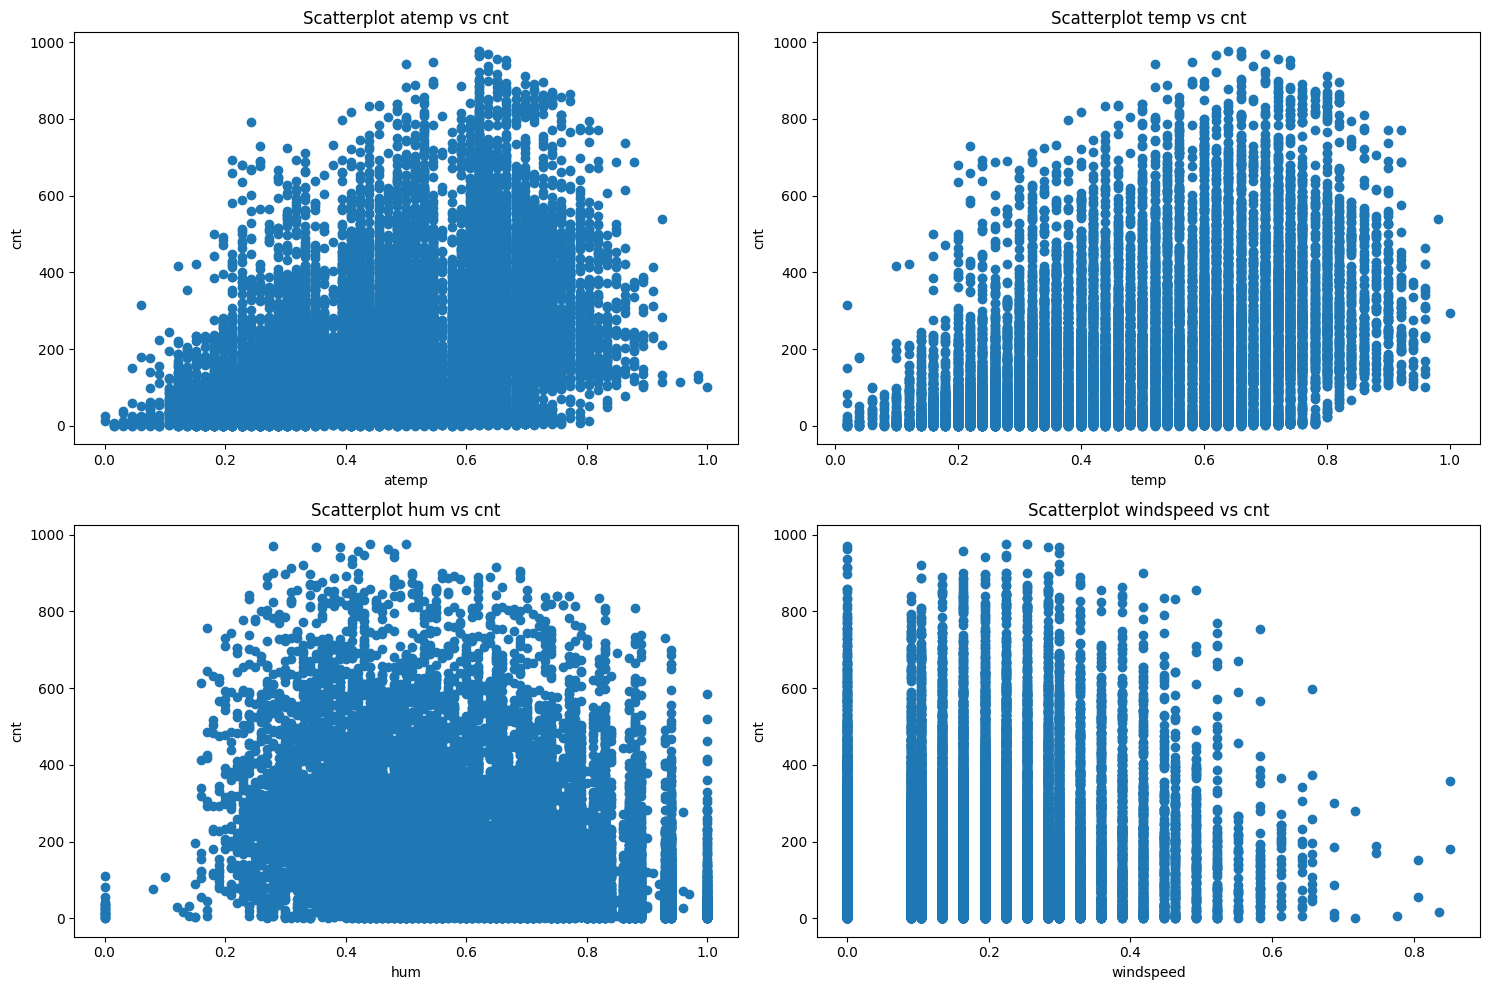

In [20]:
fig, ax = plt.subplots(2,2, figsize=(15, 10))
for var, subplot in zip(data_numerical.drop('cnt', axis =1), ax.flatten()):
  subplot.scatter(data_numerical[var], data_numerical['cnt'])
  subplot.set_title(f'Scatterplot {var} vs cnt')
  subplot.set_xlabel(var)
  subplot.set_ylabel('cnt')

plt.tight_layout()
plt.show()

**Завдання 12** побудуйте графіки співвідношення `boxplot`[boxplot](https://matplotlib.org/stable/gallery/statistics/boxplot_demo.html) між категоріальними змінними і цільовою змінною `cnt`.

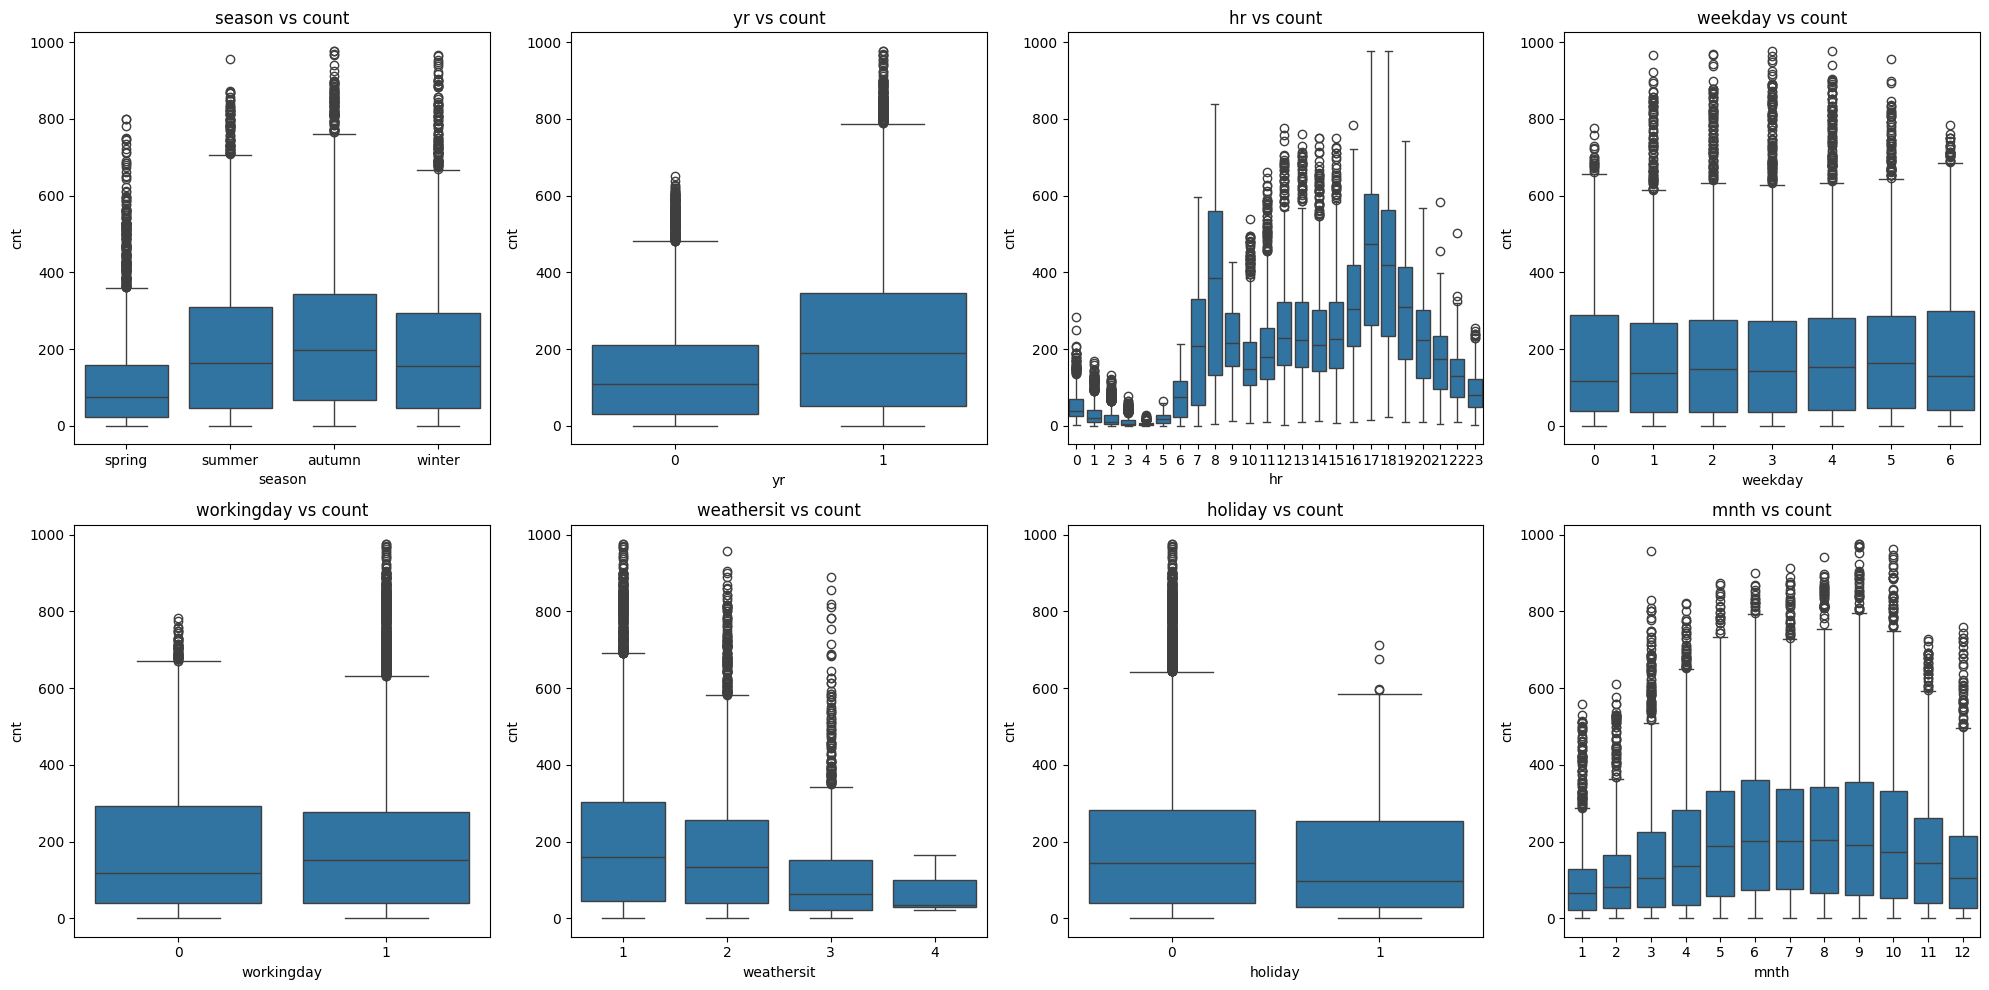

In [21]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
for var, subplot in zip(data_categorical, ax.flatten()):
  sns.boxplot(x=data_categorical[var], y=data['cnt'], ax=subplot)
  subplot.set_title(f"{var} vs count")
  subplot.set_xlabel(var)
  subplot.set_ylabel('cnt')

plt.tight_layout()
plt.show()


**Висновки з 11-12 завдання (детальні)**



У пікові години – з 7:00 до 8:00 ранку та з 17:00 до 19:00 вечора – значно зростає кількість викликів швидкої, що може бути пов’язано зі збільшенням аварій. Тому доцільно збільшувати кількість операторів кол-центру в ці проміжки часу, а після завершення години пік зменшувати штат.



**Завдання 13** Побудувати матрицю кореляції:  

1.   Вирахувати кореляційні коефіціенти для набору данних за методом Пірсона
2.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти  
3.   Вирахувати кореляційні коефіціенти для набору данних за методом Спірмана
4.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти

5. Описати отримані результати, спираючись на значення коефіціентів кореляції та пояснити в чому відмінність обраних методів.

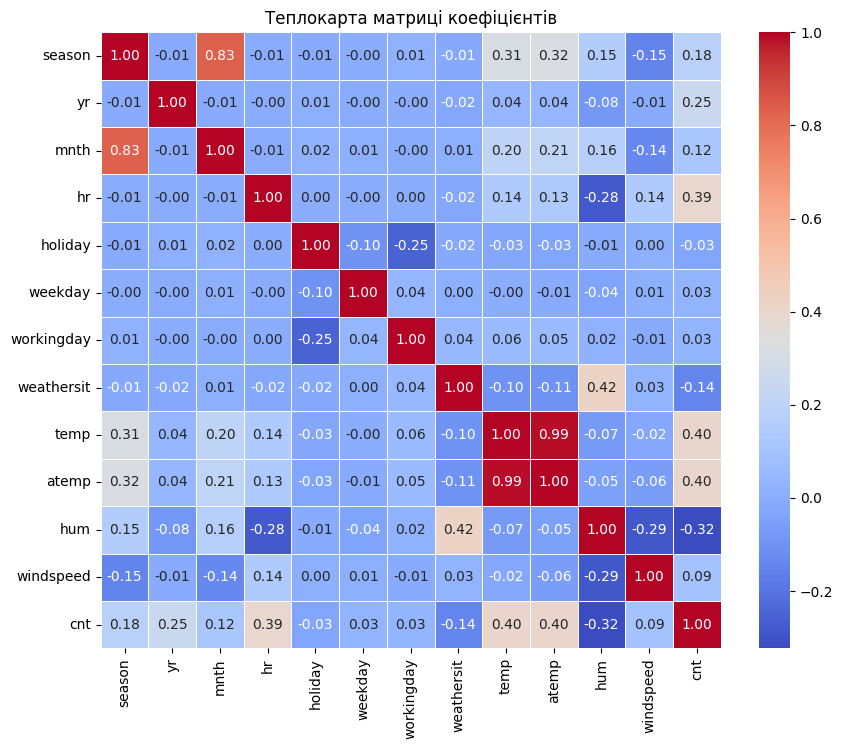

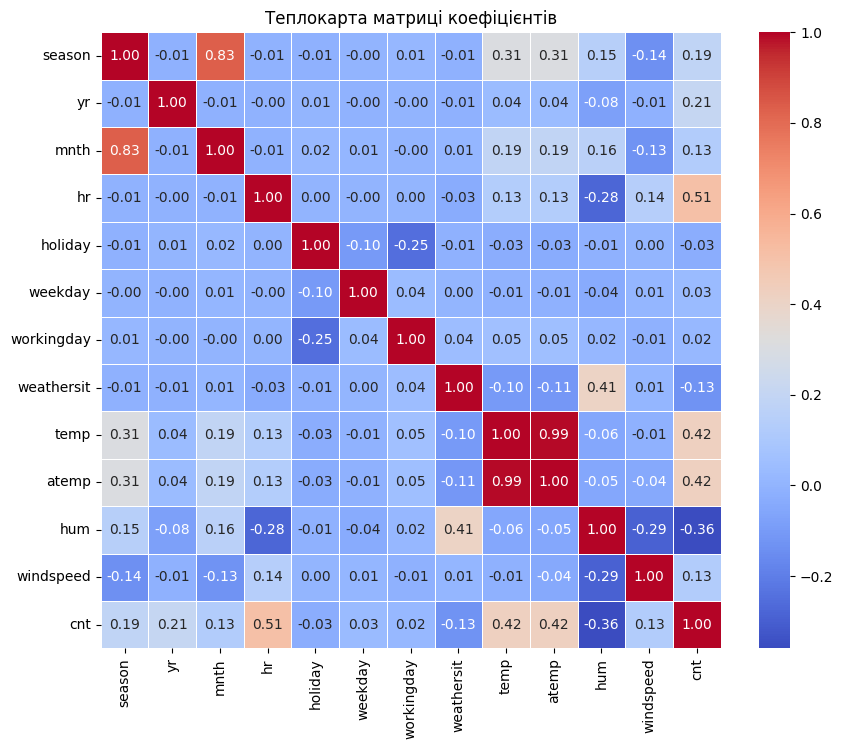

In [22]:
df_copy = data

df_copy_filtered = df_copy.drop(columns=['date', 'date_type'])
correlation_matrix_pearson = df_copy_filtered.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_pearson, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title("Теплокарта матриці коефіцієнтів")
plt.show()

correlationa_matrix_speerman = df_copy_filtered.corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(correlationa_matrix_speerman, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title("Теплокарта матриці коефіцієнтів")
plt.show()

Спостерігається сильний зв’язок між показниками `atemp` і `temp`, що може свідчити про їхню надмірну схожість. Тому, ймовірно, колонку `atemp` варто виключити, щоб уникнути надлишковості даних.  

**Завдання 14**
1. побудувати модель лінійної регресії:
2. видалити змінні, які НЕ є релевантними;

3. поділити вибірку на `train`, `test` та `validation` в пропорції `70/30`;  

4. провести навчання моделі лінійної регресії;

1. Для подальшої роботи з моделями для кожної категоріальної змінної ми створимо фіктивні змінні, щоб уникнути неправильного порядку категорій. [get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)

In [24]:
def get_dummies(df: pd.DataFrame):
  for var in categorial_columns:
    dummies = pd.get_dummies(df[var], prefix=var)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(var, axis=1)

  return df

In [25]:
features = get_dummies(data)
print('features', features)

features            date  temp   atemp   hum  windspeed  cnt            date_type  \
index                                                                      
1        1/1/11  0.24  0.2879  0.81     0.0000   16  0011-01-01 00:00:00   
2        1/1/11  0.22  0.2727  0.80     0.0000   40  0011-01-01 01:00:00   
3        1/1/11  0.22  0.2727  0.80     0.0000   32  0011-01-01 02:00:00   
4        1/1/11  0.24  0.2879  0.75     0.0000   13  0011-01-01 03:00:00   
5        1/1/11  0.24  0.2879  0.75     0.0000    1  0011-01-01 04:00:00   
...         ...   ...     ...   ...        ...  ...                  ...   
17375  12/31/12  0.26  0.2576  0.60     0.1642  119  0012-12-31 19:00:00   
17376  12/31/12  0.26  0.2576  0.60     0.1642   89  0012-12-31 20:00:00   
17377  12/31/12  0.26  0.2576  0.60     0.1642   90  0012-12-31 21:00:00   
17378  12/31/12  0.26  0.2727  0.56     0.1343   61  0012-12-31 22:00:00   
17379  12/31/12  0.26  0.2727  0.65     0.1343   49  0012-12-31 23:00:00   

  

2. На основі змінної часу створіть нову змінну, яка відповідатиме за день і ніч.

In [26]:
night_hours = [18, 19, 20, 21, 22, 23, 0, 1, 2, 3]
features['night_hours'] = data['hr'].map(lambda hr: 0 if night_hours.count(hr) == 0 else 1)
print(features['night_hours'])

index
1        1
2        1
3        1
4        1
5        0
        ..
17375    1
17376    1
17377    1
17378    1
17379    1
Name: night_hours, Length: 17379, dtype: int64


**Модель лінійної регрессії  

[train_linear_model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

Після отримання фіктивних змінних потрібно видалити по одній з кожної категорії, щоб запобігти мультиколінеарності. Також видаляємо ще два атрибути `date` та `atemp` - поясніть чому?

In [27]:
features_lr = features.drop(['season_1', 'mnth_4', 'weekday_0', 'weathersit_1', 'hr_0','atemp', 'date'], axis = 1)

In [28]:
def get_train_data(df: pd.DataFrame, target:str, test_size:float):
  X = df.drop(columns=[target, 'date_type'], axis=1)
  y = df[target]
  X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=test_size, random_state=42, shuffle = True)
  return X_train, X_test, y_train, y_test

In [30]:
X_train, X_test, y_train, y_test = get_train_data(features_lr, 'cnt', 0.3)

In [31]:
def train_linear_model(X_train, y_train):
  model = LinearRegression()
  model.fit(X_train, y_train)
  return model

model = train_linear_model(X_train, y_train)

In [32]:

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print('MSE train: {:.3f}, test: {:.3f}'.format(
        mean_squared_error(y_train, y_train_pred),
        mean_squared_error(y_test, y_test_pred)))
print('R^2 train: {:.3f}, test: {:.3f}'.format(
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred)))

MSE train: 10451.130, test: 10101.350
R^2 train: 0.688, test: 0.680


Оскільки в нашій моделі є багато незалежних змінних, ми не можемо відобразити їх залежність у двовимірному просторі, але ми можемо побудувати графік взаємозв'язку між залишками моделі та передбачуваними значеннями, що також допоможе нам оцінити якість моделі.

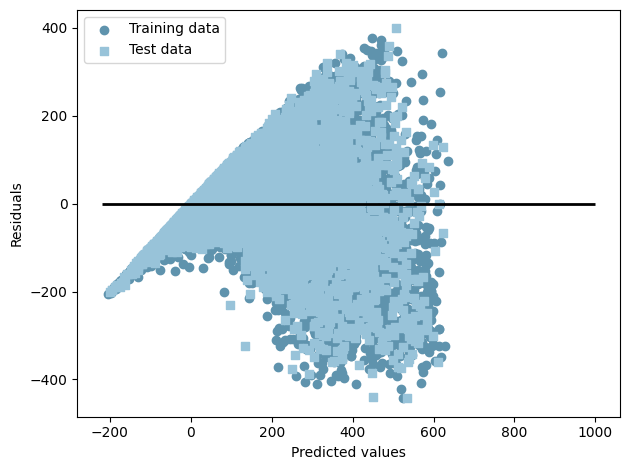

In [33]:
plt.scatter(y_train_pred,  y_train_pred - y_train,
            c='#5f93ad', marker='o', label='Training data')
plt.scatter(y_test_pred,  y_test_pred - y_test,
            c='#98c3d9', marker='s', label='Test data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.legend(loc='upper left')
plt.hlines(y=0, xmin=-220, xmax=1000, lw=2, color='#000000')
plt.tight_layout()

**Висновки з завдання (детальні)**

1. Точність моделі становить 0.68, що свідчить про можливу необхідність її доопрацювання для підвищення ефективності прогнозування.  
2. Тренувальні та тестові вибірки мають значний ступінь схожості, що вказує на мінімальні відмінності між ними.  
3. Спостерігаються викиди, які виникають через те, що модель іноді прогнозує значення, значно вищі за фактичні, що призводить до появи від’ємних залишків.

